In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from tqdm.notebook import tqdm
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('parkinson_disease.csv')
pd.set_option('display.max_columns', 10)
df.sample(5)

,id,gender,PPE,DFA,RPDE,...,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
625,208,1,0.80222,0.65975,0.44521,...,3.7249,4.5359,4.2937,33.4615,1
690,230,0,0.81282,0.72462,0.26501,...,2.3375,4.7829,6.1749,29.7681,1
709,236,0,0.78915,0.78009,0.39191,...,7.2956,9.4350,7.1035,4.8100,1
324,108,1,0.72905,0.70506,0.53729,...,4.0933,6.6329,7.7818,40.3348,1
481,160,1,0.78718,0.58615,0.36262,...,3.7703,4.5091,3.1997,3.1986,1


In [4]:
#aggregating ids so that records of same patient are not considered more than once
df = df.groupby('id').mean().reset_index()
df.drop('id', axis=1, inplace=True)

In [5]:
# Pearson correlation coefficient
columns = list(df.columns)
for col in columns:
    if col == 'class':
        continue

    filtered_columns = [col]
    for col1 in df.columns:
        if((col == col1) | (col == 'class')):
            continue

        val = df[col].corr(df[col1])
        if val > 0.7:
            # If the correlation between the two features is more than 0.7, remove it
            columns.remove(col1)
            continue
        else:
            filtered_columns.append(col1)

    df = df[filtered_columns]
df.shape

(252, 274)

In [7]:
# feature selection using chi-square
X = df.drop('class', axis=1)
X_norm = MinMaxScaler().fit_transform(X)
selector = SelectKBest(chi2, k=30)
selector.fit(X_norm, df['class'])
filtered_columns = selector.get_support()
filtered_data = X.loc[:, filtered_columns]
filtered_data['class'] = df['class']
df = filtered_data
df.shape

(252, 31)

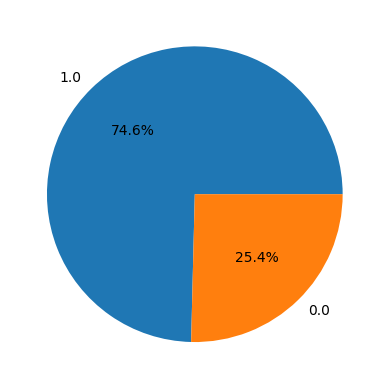

In [8]:
x = df['class'].value_counts()
plt.pie(x.values,
        labels = x.index,
        autopct='%1.1f%%')
plt.show()

In [9]:
features = df.drop('class', axis=1)
target = df['class']

X_train, X_val,Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.2,
                                      random_state=10)

ros = RandomOverSampler(sampling_strategy=1.0,
                        random_state=0)
X, Y = ros.fit_resample(X_train, Y_train)
X.shape, Y.value_counts()

((302, 30),
 class
 1.0    151
 0.0    151
 Name: count, dtype: int64)

In [10]:
features = df.drop('class', axis=1)
target = df['class']

X_train, X_val,Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.2,
                                      random_state=10)

ros = RandomOverSampler(sampling_strategy=1.0,
                        random_state=0)
X, Y = ros.fit_resample(X_train, Y_train)
X.shape, Y.value_counts()

((302, 30),
 class
 1.0    151
 0.0    151
 Name: count, dtype: int64)

In [12]:
from sklearn.metrics import roc_auc_score as ras

models = [LogisticRegression(class_weight='balanced'), XGBClassifier(), SVC(kernel='rbf', probability=True)]
for model in models:
    model.fit(X, Y)
    print(f'{model} : ')

    train_preds = model.predict(X)
    print('Training Accuracy : ', ras(Y, train_preds))

    val_preds = model.predict(X_val)
    print('Validation Accuracy : ', ras(Y_val, val_preds))
    print()

LogisticRegression(class_weight='balanced') : 
Training Accuracy :  0.7483443708609271
Validation Accuracy :  0.7625482625482626

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  1.0
Validation Accuracy :  0.745173745173745

SVC(probability=True) : 
Training Accura

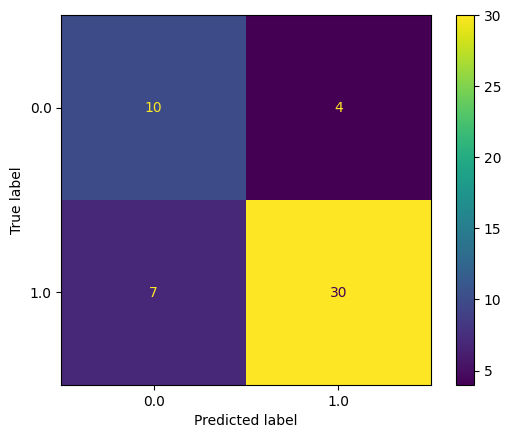

In [13]:
# logidtic regression gives the best result
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(models[0], X_val, Y_val)
plt.show()

Alternate Approach

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import re

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv('parkinson_disease.csv')

df_patient = df.groupby('id').mean().reset_index()

X = df_patient.drop(columns=['id', 'class'])
y = df_patient['class'].astype(int)

print(f"Dataset shape after patient aggregation: {X.shape}")
print(f"Class balance:\n{y.value_counts()}")

Dataset shape after patient aggregation: (252, 753)
Class balance:
class
1    188
0     64
Name: count, dtype: int64


In [16]:
class SafeMinMaxScaler(MinMaxScaler):
    """Clips negative values to 0 during transform so chi2 doesn't fail on test folds."""
    def transform(self, X):
        X_tf = super().transform(X)
        return np.clip(X_tf, 0, None)

class CorrelationFilter(BaseEstimator, TransformerMixin):
    """Drops highly correlated features. Fits ONLY on training data."""
    def __init__(self, threshold=0.7):
        self.threshold = threshold
        self.drop_indices_ = []

    def fit(self, X, y=None):
        # Calculate correlation matrix only on the data passed to fit()
        corr_matrix = pd.DataFrame(X).corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.drop_indices_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
        return self

    def transform(self, X):
        # Drop the indices identified during fit()
        return np.delete(X, self.drop_indices_, axis=1)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

In [17]:
# Define models and modest hyperparameter grids for inner CV
models = {
    'LR': (LogisticRegression(max_iter=1000, random_state=42), {'clf__C': [0.1, 1.0, 10.0]}),
    'XGB': (XGBClassifier(random_state=42, eval_metric='logloss'), {'clf__learning_rate': [0.01, 0.1, 0.2], 'clf__max_depth': [3, 5, 7]}),
    'SVC': (SVC(probability=True, random_state=42), {'clf__C': [0.1, 1.0, 10.0], 'clf__gamma': ['scale', 'auto']})
}

cv_outer = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
results = []

for name, (base_model, param_grid) in models.items():
    print(f"Running Nested CV for {name}...")

    # Strict order: Scale -> Filter Correlated -> Select K -> Oversample -> Train
    pipeline = Pipeline([
        ('scaler', SafeMinMaxScaler()),
        ('corr_filter', CorrelationFilter(threshold=0.7)),
        ('selector', SelectKBest(score_func=chi2, k=30)),
        ('sampler', RandomOverSampler(random_state=42)),
        ('clf', base_model)
    ])

    search = RandomizedSearchCV(pipeline, param_grid, n_iter=5, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)

    for fold_idx, (train_ix, test_ix) in enumerate(cv_outer.split(X, y)):
        X_train, X_test = X.iloc[train_ix], X.iloc[test_ix]
        y_train, y_test = y.iloc[train_ix], y.iloc[test_ix]

        search.fit(X_train, y_train)
        best_model = search.best_estimator_

        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:, 1]

        results.append({
            'Model': name,
            'Fold': fold_idx,
            'ROC-AUC': roc_auc_score(y_test, y_prob),
            'F1': f1_score(y_test, y_pred),
            'Sensitivity': recall_score(y_test, y_pred),
            'Specificity': specificity_score(y_test, y_pred)
        })

df_results = pd.DataFrame(results)
summary = df_results.groupby('Model').agg(['mean', 'std'])
print("\nLeakage-Free Nested CV Results (Mean +/- Std):")
display(summary)

Running Nested CV for LR...
Running Nested CV for XGB...
Running Nested CV for SVC...

Leakage-Free Nested CV Results (Mean +/- Std):


Fold             ROC-AUC                  F1           Sensitivity  \
       mean       std      mean       std      mean       std        mean   
Model                                                                       
LR     12.0  7.359801  0.756598  0.083845  0.785269  0.050292    0.730441   
SVC    12.0  7.359801  0.723453  0.078848  0.793952  0.058289    0.756017   
XGB    12.0  7.359801  0.763251  0.070879  0.850897  0.044271    0.873115   

                Specificity            
            std        mean       std  
Model                                  
LR     0.063321    0.625897  0.117208  
SVC    0.081778    0.575641  0.144575  
XGB    0.062698    0.478974  0.126125

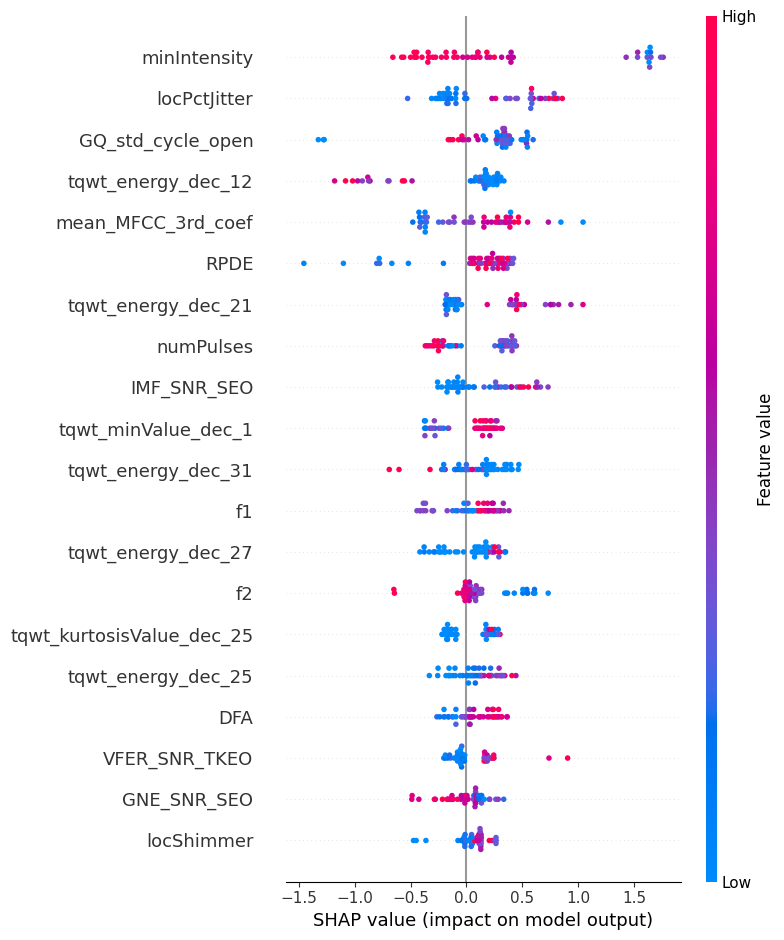

In [18]:
# Categorize acoustic features via regex
def get_feature_family(feature_name):
    name = str(feature_name).lower()
    if re.search(r'(jitter|shimmer)', name): return 'Jitter/Shimmer'
    if 'mfcc' in name: return 'MFCC'
    if 'tqwt' in name or 'wavelet' in name: return 'Wavelet/TQWT'
    if 'entropy' in name: return 'Entropy'
    return 'Other'

# Train best model (e.g., XGB) on a single 80/20 split to extract SHAP
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
best_pipeline = Pipeline([
    ('scaler', SafeMinMaxScaler()),
    ('corr_filter', CorrelationFilter(threshold=0.7)),
    ('selector', SelectKBest(score_func=chi2, k=30)),
    ('sampler', RandomOverSampler(random_state=42)),
    ('clf', XGBClassifier(random_state=42, max_depth=3, learning_rate=0.1))
])

best_pipeline.fit(X_train, y_train)

# Manually push test data through preprocessing to get SHAP inputs
X_test_scaled = best_pipeline.named_steps['scaler'].transform(X_test)
X_test_corr = best_pipeline.named_steps['corr_filter'].transform(X_test_scaled)
X_test_final = best_pipeline.named_steps['selector'].transform(X_test_corr)

# Map surviving feature names
feats_after_corr = np.delete(X.columns.values, best_pipeline.named_steps['corr_filter'].drop_indices_)
surviving_features = feats_after_corr[best_pipeline.named_steps['selector'].get_support()]

# TreeExplainer for XGBoost
explainer = shap.TreeExplainer(best_pipeline.named_steps['clf'])
shap_values = explainer.shap_values(X_test_final)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_final, feature_names=surviving_features)

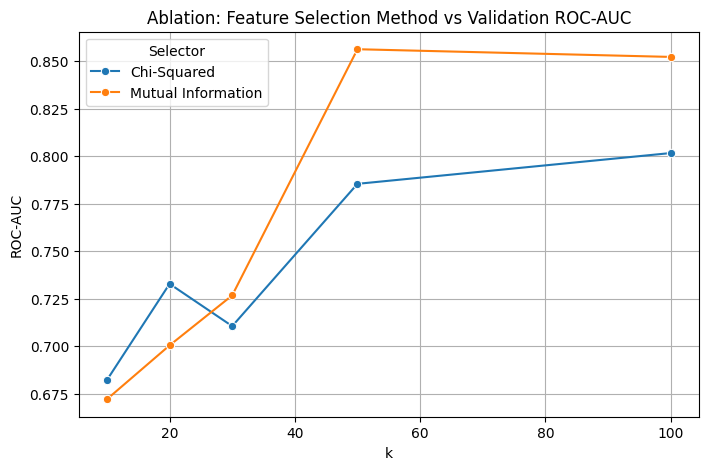

In [19]:
k_values = [10, 20, 30, 50, 100]
selectors = {'Chi-Squared': chi2, 'Mutual Information': mutual_info_classif}
ablation_results = []

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

for sel_name, score_func in selectors.items():
    for k in k_values:
        pipe = Pipeline([
            ('scaler', SafeMinMaxScaler()),
            ('corr_filter', CorrelationFilter(threshold=0.7)),
            ('selector', SelectKBest(score_func=score_func, k=k)),
            ('sampler', RandomOverSampler(random_state=42)),
            ('clf', LogisticRegression(max_iter=1000, random_state=42))
        ])

        pipe.fit(X_train, y_train)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        ablation_results.append({'Selector': sel_name, 'k': k, 'ROC-AUC': auc})

df_ablation = pd.DataFrame(ablation_results)
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_ablation, x='k', y='ROC-AUC', hue='Selector', marker='o')
plt.title('Ablation: Feature Selection Method vs Validation ROC-AUC')
plt.grid(True)
plt.show()